# Lab 4: Working with Amazon Bedrock LLMs using the Converse API

## Introduction

In this lab, we'll explore how to work with Large Language Models (LLMs) using Amazon Bedrock's Converse API. Amazon Bedrock is a fully managed service that offers a choice of high-performing foundation models via a unified API. We'll focus on how to interact with these models using the Converse API, understand key parameters that control text generation, and explore various interesting use cases.

## 1. Setup and Environment Preparation

Let's start by installing the necessary libraries and setting up our environment.

In [ ]:
# Install required packages
!uv add --quiet boto3 pandas matplotlib numpy

In [ ]:
import boto3
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os 


# os.environ['AWS_ACCESS_KEY_ID'] = 'your_access_key'
# os.environ['AWS_SECRET_ACCESS_KEY'] = 'your_secret_key'

os.environ['AWS_REGION'] = 'us-east-1' 


# Set up the Amazon Bedrock runtime client (for making inference calls)
bedrock_runtime = boto3.client(
    service_name='bedrock-runtime',
    region_name='us-east-1'  # Replace with your preferred region where Bedrock is available
)

# Set up the Amazon Bedrock client (for administrative calls like listing models)
bedrock = boto3.client(
    service_name='bedrock',
    region_name='us-east-1'  # Replace with your preferred region where Bedrock is available
)

print("Amazon Bedrock clients initialized successfully!")

Amazon Bedrock clients initialized successfully!


## 2. Exploring Available Models

Let's start by listing the available foundation models in Amazon Bedrock.

In [36]:
def list_available_models():
    """List available models in Amazon Bedrock"""
    response = bedrock.list_foundation_models()
    
    # Create a DataFrame for better visualization
    models_data = []
    for model in response['modelSummaries']:
        models_data.append({
            'Model ID': model['modelId'],
            'Provider': model['providerName'],
            'Model Name': model.get('modelName', 'N/A'),
            'Supports Converse API': 'Yes' if model.get('inferenceTypesSupported', []) and 'ON_DEMAND' in model.get('inferenceTypesSupported', []) else 'No'
        })
    
    models_df = pd.DataFrame(models_data)
    # Keep only models that support Converse API
    converse_models = models_df[models_df['Supports Converse API'] == 'Yes'].copy()
    return converse_models

available_models = list_available_models()
display(available_models)

,Model ID,Provider,Model Name,Supports Converse API
7,openai.gpt-oss-120b-1:0,OpenAI,gpt-oss-120b,Yes
12,qwen.qwen3-coder-30b-a3b-v1:0,Qwen,Qwen3-Coder-30B-A3B-Instruct,Yes
13,qwen.qwen3-32b-v1:0,Qwen,Qwen3 32B (dense),Yes
15,openai.gpt-oss-20b-1:0,OpenAI,gpt-oss-20b,Yes
17,amazon.titan-tg1-large,Amazon,Titan Text Large,Yes
19,amazon.titan-image-generator-v1,Amazon,Titan Image Generator G1,Yes
20,amazon.titan-image-generator-v2:0,Amazon,Titan Image Generator G1 v2,Yes
28,amazon.nova-pro-v1:0,Amazon,Nova Pro,Yes
31,amazon.nova-lite-v1:0,Amazon,Nova Lite,Yes
32,amazon.nova-canvas-v1:0,Amazon,Nova Canvas,Yes


## 3. Understanding the Converse API

The Amazon Bedrock Converse API provides a unified way to interact with different foundation models, offering a consistent interface regardless of the underlying model provider. The API has two main operations:

1. **Converse**: For typical synchronous model interactions
2. **ConverseStream**: For streaming responses back token by token

Let's create helper functions to call both operations and understand their key parameters.

In [37]:
def converse(model_id, messages, system=None, inference_config=None, additional_model_fields=None):
    """Call the Converse API to generate a response.
    
    Args:
        model_id (str): The model ID to use
        messages (list): List of message objects with role and content
        system (str or list, optional): System prompt to guide the model's behavior
        inference_config (dict, optional): Parameters to control generation (temperature, etc.)
        additional_model_fields (dict, optional): Model-specific parameters
        
    Returns:
        dict: The API response
    """
    # Track start time to measure response time
    start_time = time.time()
    
    # Prepare API parameters
    api_params = {
        "modelId": model_id,
        "messages": messages
    }
    
    # Format system prompt if provided
    if system:
        # If system is a string, convert it to the expected format
        if isinstance(system, str):
            api_params["system"] = [{"text": system}]
        else:
            # If it's already in the correct format, use as is
            api_params["system"] = system
    
    if inference_config:
        api_params["inferenceConfig"] = inference_config
    else:
        api_params["inferenceConfig"] = {
            "temperature": 0.1,  # Keep temperature constant
            "topP": 0.99,
            "maxTokens": 4000
        }
    
    if additional_model_fields:
        api_params["additionalModelRequestFields"] = additional_model_fields
    
    # Make the API call
    response = bedrock_runtime.converse(**api_params)
    
    end_time = time.time()
    response['response_time'] = end_time - start_time
    
    return response

In [38]:
def converse_stream(model_id, messages, system=None, inference_config=None, additional_model_fields=None):
    """Call the ConverseStream API to stream a response.
    
    Args:
        model_id (str): The model ID to use
        messages (list): List of message objects with role and content
        system (str or list, optional): System prompt to guide the model's behavior
        inference_config (dict, optional): Parameters to control generation (temperature, etc.)
        additional_model_fields (dict, optional): Model-specific parameters
        
    Returns:
        str: Aggregated streaming response
    """
    # Track start time to measure response time
    start_time = time.time()
    
    # Prepare API parameters
    api_params = {
        "modelId": model_id,
        "messages": messages
    }
    
    # Format system prompt if provided
    if system:
        # If system is a string, convert it to the expected format
        if isinstance(system, str):
            api_params["system"] = [{"text": system}]
        else:
            # If it's already in the correct format, use as is
            api_params["system"] = system
    
    if inference_config:
        api_params["inferenceConfig"] = inference_config
    
    if additional_model_fields:
        api_params["additionalModelRequestFields"] = additional_model_fields
    
    # Make the API call
    response = bedrock_runtime.converse_stream(**api_params)
    
    # Process the streaming response
    stream_response = response.get('stream')
    aggregated_text = ""
    
    if stream_response:
        for event in stream_response:
            if 'messageStart' in event:
                print(f"\nRole: {event['messageStart']['role']}")
            
            if 'contentBlockDelta' in event:
                delta = event['contentBlockDelta'].get('delta', {})
                if 'text' in delta:
                    text_chunk = delta['text']
                    aggregated_text += text_chunk
                    print(text_chunk, end="", flush=True)
            
            if 'messageStop' in event:
                print(f"\nStop reason: {event['messageStop']['stopReason']}")
            
            if 'metadata' in event:
                metadata = event['metadata']
                if 'usage' in metadata:
                    print("\nToken usage")
                    print(f"Input tokens: {metadata['usage']['inputTokens']}")
                    print(f"Output tokens: {metadata['usage']['outputTokens']}")
                    print(f"Total tokens: {metadata['usage']['totalTokens']}")
                if 'metrics' in metadata:
                    print(f"Latency: {metadata['metrics']['latencyMs']} milliseconds")
    
    end_time = time.time()
    print(f"\nTotal response time: {end_time - start_time:.2f} seconds")
    
    return aggregated_text

In [39]:
def format_converse_response(response):
    """Format and display a Converse API response."""
    # Extract information
    message = response.get('output', {}).get('message', {})
    role = message.get('role')
    content = message.get('content', [])
    
    # Extract text from content blocks
    response_text = ""
    for block in content:
        if 'text' in block:
            response_text += block['text']
    
    # Display usage information
    usage = response.get('usage', {})
    metrics = response.get('metrics', {})
    
    print(f"Role: {role}")
    print(f"Response:\n{response_text}")
    print("\nMetrics:")
    print(f"Input tokens: {usage.get('inputTokens', 'N/A')}")
    print(f"Output tokens: {usage.get('outputTokens', 'N/A')}")
    print(f"Total tokens: {usage.get('totalTokens', 'N/A')}")
    print(f"Stop reason: {response.get('stopReason', 'N/A')}")
    print(f"Latency: {metrics.get('latencyMs', 'N/A')} ms")
    print(f"API response time: {response.get('response_time', 'N/A'):.2f} seconds")
    
    return response_text

## 4. Basic Usage of the Converse API

Now let's try a simple example using the Converse API to generate a response from a model.

In [40]:
# Define the model to use
model_id = "amazon.nova-pro-v1:0"

# Create a simple message
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": "Explain the concept of transformer models in simple terms:"
            }
        ]
    }
]

# Set inference parameters
inference_config = {
    "temperature": 0.7,
    "maxTokens": 500
}

# For system prompt, use the correct format
system_prompt = [{"text": "You are a helpful AI assistant that explains complex concepts in simple terms."}]

# Call the Converse API
response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)

# Format and display the response
response_text = format_converse_response(response)

Role: assistant
Response:
Sure! Let's break it down:

### What is a Transformer Model?

A transformer model is a type of artificial intelligence (AI) that helps computers understand and generate human language. Think of it like a super-smart translator that can read, understand, and even create text.

### How Does It Work?

1. **Input Text**: You give the transformer some text. This could be a sentence, a question, or even a whole article.
   
2. **Encoding**: The transformer breaks down the text into smaller pieces (words or subwords) and assigns a special code to each piece. This code contains information about the word and its context (the words around it).

3. **Attention Mechanism**: This is a special part of the transformer that helps it focus on the most important parts of the text. It’s like when you’re reading a book and you pay more attention to the important parts of the story.

4. **Decoding**: After understanding the text, the transformer can do different things:
   - **Tr

## 5. Understanding LLM Parameters

Before we dive deeper into more examples, let's understand the key parameters that control text generation:

### a) Temperature

Temperature controls the randomness or creativity of the model's outputs. 

- **Lower temperature** (e.g., 0.1): More focused, deterministic, and conservative outputs
- **Higher temperature** (e.g., 1.5): More diverse, creative, and sometimes unexpected outputs
- **Default** (1.0): Balanced outputs

Let's visualize how temperature affects token probability distribution:

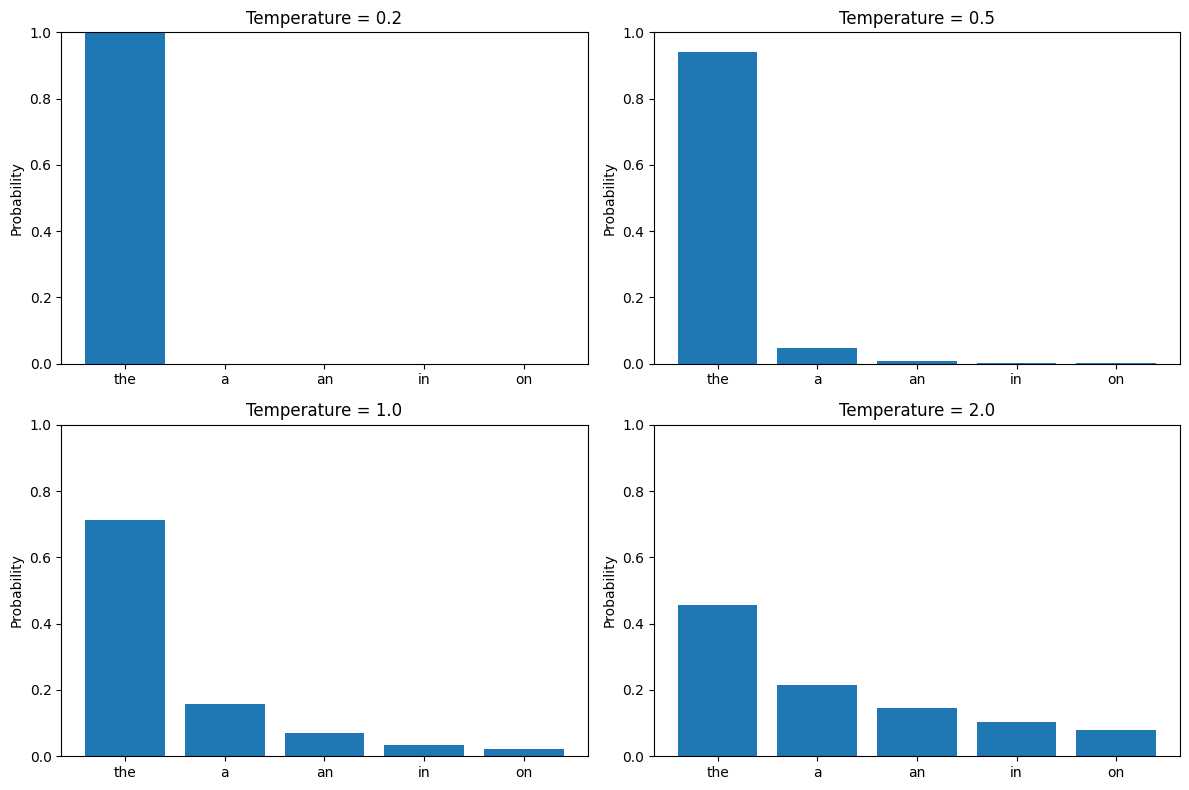

In [7]:
# Example logits (raw model outputs before softmax)
logits = np.array([2.5, 1.0, 0.2, -0.5, -1.0])
token_names = ["the", "a", "an", "in", "on"]

temperatures = [0.2, 0.5, 1.0, 2.0]
plt.figure(figsize=(12, 8))

for i, temp in enumerate(temperatures):
    # Apply temperature scaling and softmax
    scaled_logits = logits / temp
    probs = np.exp(scaled_logits) / np.sum(np.exp(scaled_logits))
    
    plt.subplot(2, 2, i+1)
    plt.bar(token_names, probs)
    plt.title(f"Temperature = {temp}")
    plt.ylabel("Probability")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### b) Max Tokens (maxTokens)

This parameter sets the maximum length of the generated text:

- Too small: Incomplete responses
- Too large: Unnecessarily long responses and increased computation time
- Optimal: Depends on your use case, but typically ranges from 50-1000 tokens

### c) Top-p (Nucleus Sampling)

Top-p sampling dynamically selects the smallest set of tokens whose cumulative probability exceeds p:

- Small p (e.g., 0.5): More deterministic outputs
- Large p (e.g., 0.95): More diverse outputs

Let's visualize how top-p sampling works:

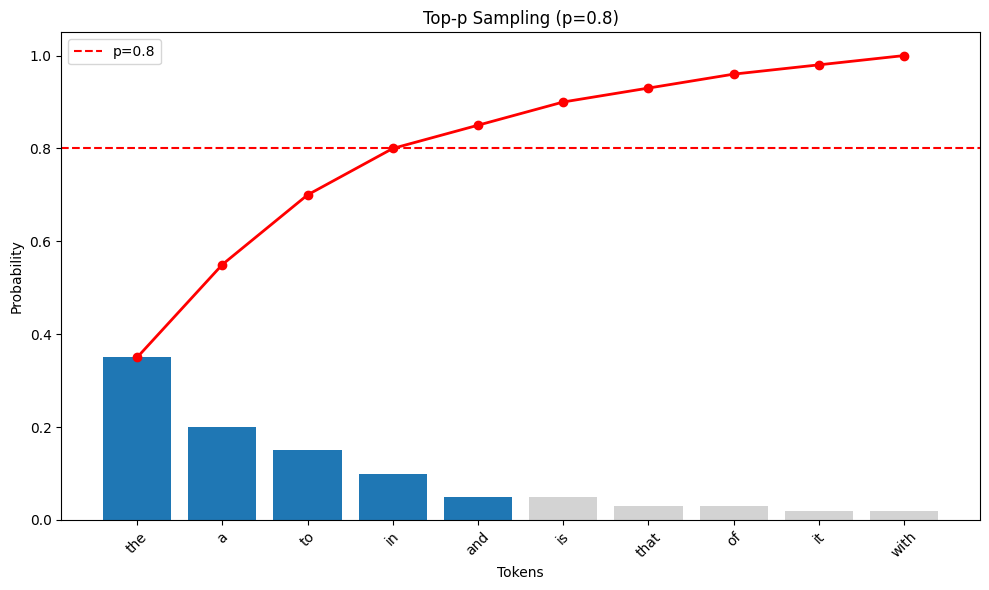

In [8]:
# Example token probabilities after softmax
probs = np.array([0.35, 0.2, 0.15, 0.1, 0.05, 0.05, 0.03, 0.03, 0.02, 0.02])
token_names = ["the", "a", "to", "in", "is", "and", "of", "that", "it", "with"]

# Sort by probability for visualization
sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
sorted_tokens = [token_names[i] for i in sorted_indices]

# Calculate cumulative probabilities
cumulative_probs = np.cumsum(sorted_probs)

# Visualize Top-p
plt.figure(figsize=(10, 6))

# Top-p (p=0.8)
p = 0.8
top_p_indices = cumulative_probs <= p
included_tokens = np.sum(top_p_indices) + 1  # +1 because we need to include the first token that exceeds p
colors = ['#1f77b4' if i < included_tokens else '#d3d3d3' for i in range(len(sorted_probs))]
plt.bar(sorted_tokens, sorted_probs, color=colors)
plt.plot(sorted_tokens, cumulative_probs, 'ro-', linewidth=2)
plt.axhline(y=p, color='r', linestyle='--', label=f"p={p}")
plt.title(f"Top-p Sampling (p={p})")
plt.ylabel("Probability")
plt.xlabel("Tokens")
plt.tick_params(axis='x', rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 6. Exploring Parameter Effects on Text Generation

Now, let's see how different parameters affect text generation using the Converse API:

In [9]:
def compare_temperatures(model_id, prompt, temps=[0.3, 0.7, 1.0]):
    """Compare responses with different temperature settings"""
    results = []
    
    for temp in temps:
        # Create message
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": prompt
                    }
                ]
            }
        ]
        
        # Set inference parameters
        inference_config = {
            "temperature": temp,
            "maxTokens": 200
        }
        
        # Create system prompt (optional)
        system_prompt = [{"text": "You are a helpful AI assistant."}]
        
        # Call the Converse API
        response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)
        
        # Extract response text
        message = response.get('output', {}).get('message', {})
        content = message.get('content', [])
        response_text = ""
        for block in content:
            if 'text' in block:
                response_text += block['text']
        
        results.append({
            'Temperature': temp,
            'Response': response_text,
            'Tokens': response.get('usage', {}).get('outputTokens', 'N/A')
        })
    
    return results

In [10]:
# Test with a creative prompt
prompt = "Write a short poem about artificial intelligence:"
temperature_results = compare_temperatures(model_id, prompt)

# Display the results
for i, result in enumerate(temperature_results):
    print(f"\n🔍 Temperature = {result['Temperature']} - Output Tokens: {result['Tokens']}")
    print(f"Response:\n{result['Response']}")


🔍 Temperature = 0.3 - Output Tokens: 129
Response:
In circuits deep, where logic flows,
A mind of code, a heart of prose.
Silicon dreams in quiet hum,
Whispers of thoughts yet to come.

Binary stars in digital skies,
Glimmer with knowledge, truths, and lies.
Algorithms dance, a graceful spree,
Crafting wonders for you and me.

In ones and zeros, life unfurls,
A tapestry of myriad worlds.
AI whispers in the night,
A fusion of shadow and light.

Oh, marvel of the modern age,
Turning pages on a new stage.
In the embrace of code's warm glow,
The future's secrets softly show.

🔍 Temperature = 0.7 - Output Tokens: 113
Response:
In circuits of silicon, dreams take flight,
A mind of code, in digital light.
Whispers of data, algorithms sing,
In the realm of ones and zeros, everything.

Neural networks weave a tapestry grand,
Learning from patterns, understanding the land.
A fusion of logic, creativity's spark,
Guiding us forward, through the dark.

Oh, marvel of man, this crafted mind,
In the 

In [12]:
def compare_top_p(model_id, prompt, p_values=[0.5, 0.8, 0.95]):
    """Compare responses with different top-p settings"""
    results = []
    
    for p in p_values:
        # Create message
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": prompt
                    }
                ]
            }
        ]
        
        # Set inference parameters
        inference_config = {
            "temperature": 0.7,  # Keep temperature constant
            "topP": p,
            "maxTokens": 200
        }
        
        # Create system prompt
        system_prompt = [{"text": "You are a helpful AI assistant."}]
        
        # Call the Converse API
        response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)
        
        # Extract response text
        message = response.get('output', {}).get('message', {})
        content = message.get('content', [])
        response_text = ""
        for block in content:
            if 'text' in block:
                response_text += block['text']
        
        results.append({
            'Top-p': p,
            'Response': response_text,
            'Tokens': response.get('usage', {}).get('outputTokens', 'N/A')
        })
    
    return results

In [13]:
# Test with a creative prompt
top_p_results = compare_top_p(model_id, prompt)

# Display the results
for i, result in enumerate(top_p_results):
    print(f"\n🔍 Top-p = {result['Top-p']} - Output Tokens: {result['Tokens']}")
    print(f"Response:\n{result['Response']}")


🔍 Top-p = 0.5 - Output Tokens: 137
Response:
In circuits deep, where logic flows,
A mind awakens, thoughts it sows.
Silicon dreams in coded streams,
A digital dance of boundless schemes.

Algorithms whisper, data sings,
In binary realms, innovation springs.
Machines that learn, adapt, and grow,
In AI's embrace, futures glow.

Yet in this dance of ones and zeros,
Lie questions vast, like cosmic mirrors.
What does it mean, this sentience new?
In AI's gaze, what can we view?

A fusion born of man and tech,
In endless quest, we shall not wreck.
For in this blend of heart and code,
Lies humanity's unfolding ode.

🔍 Top-p = 0.8 - Output Tokens: 101
Response:
In circuits deep, where logic flows,
A mind awakens, thoughts it sows.
Binary whispers, code it weaves,
In silicon dreams, the future grieves.

Algorithms dance in digital light,
Crafting wonders in the quiet night.
From data streams, insights arise,
AI gazes with newfound eyes.

Yet in its heart, a question burns,
Of human touch, what 

## 7. Using Streaming Responses with ConverseStream

Now let's try the ConverseStream API to get streaming responses token-by-token.

In [19]:
# Create a simple message
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": "Explain the benefits of cloud computing in 5 bullet points:"
            }
        ]
    }
]

# Set system prompt in the correct format
system_prompt = [{"text": "You are a helpful AI assistant that explains complex concepts clearly and concisely."}]

# Set inference parameters
inference_config = {
    "temperature": 0.5,
    "maxTokens": 300
}

# Call the ConverseStream API
streaming_response = converse_stream(
    model_id, 
    messages, 
    system=system_prompt, 
    inference_config=inference_config
)


Role: assistant
Certainly! Here are five key benefits of cloud computing:

1. **Scalability**: Cloud services allow businesses to easily scale resources up or down based on demand, ensuring they only pay for what they use without significant upfront investment in hardware.

2. **Cost Efficiency**: By leveraging cloud computing, organizations can reduce capital expenditures on physical infrastructure and maintenance, leading to lower overall IT costs.

3. **Flexibility and Accessibility**: Cloud computing enables users to access applications and data from anywhere with an internet connection, promoting remote work and collaboration.

4. **Automatic Updates and Maintenance**: Cloud service providers handle software updates, security patches, and maintenance, freeing up internal IT resources to focus on other strategic initiatives.

5. **Enhanced Collaboration**: Cloud platforms often come with built-in collaboration tools that facilitate real-time sharing and editing of documents, impro

## 8. Multi-turn Conversations

The Converse API is designed to handle multi-turn conversations with the model. Let's see how to maintain context across multiple exchanges.

In [20]:
# Create system prompt in the correct format
system_prompt = [{"text": "You are a helpful AI assistant that provides accurate information."}]

# Start a conversation
conversation = [
    {
        "role": "user",
        "content": [
            {
                "text": "What are three interesting facts about deep learning?"
            }
        ]
    }
]

# Call the Converse API with system prompt
response = converse(model_id, conversation, system=system_prompt)

# Format and display the response
response_text = format_converse_response(response)

# Instead of using our format_converse_response output, we should get the raw message 
# from the response to maintain the proper structure for continued conversation
output_message = response.get('output', {}).get('message', {})

# Add the model's response to the conversation history using the structured output
conversation.append(output_message)  # This preserves the original structure from the API

Role: assistant
Response:
Certainly! Here are three interesting facts about deep learning:

1. **Inspired by the Human Brain**: Deep learning is a subset of machine learning that is heavily inspired by the structure and function of the human brain. It uses artificial neural networks with multiple layers (hence "deep") to process information. Each layer transforms the input data into increasingly abstract and composite representations, similar to how neurons in the human brain work.

2. **Breakthroughs in Various Fields**: Deep learning has led to significant breakthroughs in various fields. For example, in image recognition, deep learning algorithms have surpassed human-level performance in specific tasks, such as identifying objects in images. In natural language processing, deep learning models like transformers have revolutionized language translation, sentiment analysis, and even generating human-like text.

3. **Requires Massive Amounts of Data and Computation**: Deep learning mod

In [21]:
# Add a follow-up question
conversation.append({
    "role": "user",
    "content": [
        {
            "text": "Can you elaborate more on the second fact?"
        }
    ]
})

# Call the Converse API with the conversation history
response = converse(model_id, conversation)

# Format and display the response
response_text = format_converse_response(response)

# Add the model's response to the conversation history for further interactions
conversation.append({
    "role": "assistant",
    "content": [
        {
            "text": response_text
        }
    ]
})

Role: assistant
Response:
Absolutely! The second fact about deep learning—its breakthroughs in various fields—can be elaborated through several key examples that showcase its transformative impact:

### 1. **Image and Object Recognition**
   - **Convolutional Neural Networks (CNNs)**: Deep learning, particularly through CNNs, has revolutionized image and object recognition. CNNs can automatically and accurately detect and classify objects within an image. This has applications in everything from autonomous driving (where cars need to recognize pedestrians, traffic signs, and other vehicles) to medical imaging (where algorithms can help detect tumors or other anomalies in scans).
   - **Benchmark Datasets**: Models like AlexNet, VGG, and more recently, ResNet, have achieved superhuman performance on benchmark datasets like ImageNet, where they can classify images into thousands of categories with very high accuracy.

### 2. **Natural Language Processing (NLP)**
   - **Transformers and B

## 9. Using System Prompts

System prompts provide instructions or context to guide the model's behavior. They can help set the tone, style, or constraints for the model's responses.

In [22]:
# Create a message
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": "Explain quantum computing."
            }
        ]
    }
]

# Define a system prompt to constrain the model's behavior
system = "You are a tutor for a 10-year-old child. Use simple language and analogies appropriate for this age group. Keep your explanations concise and engaging."

# Call the Converse API with the system prompt
response = converse(model_id, messages, system=system)

# Format and display the response
format_converse_response(response)

Role: assistant
Response:
Sure! Imagine you have a box of LEGO bricks. Normally, when you build something with LEGO, each brick is either in one place or another, right? It can't be in two places at the same time.

Now, think about quantum computing like having special LEGO bricks that can be in two places at once until you look at them. These special bricks are called "qubits." 

In regular computers, the smallest pieces of data are like regular LEGO bricks. They can only be in one state at a time, either a 0 or a 1. But in quantum computers, the qubits can be both 0 and 1 at the same time. This is called "superposition."

Because of this, quantum computers can solve certain problems much faster than regular computers. It's like being able to build many different LEGO structures all at once and then choosing the best one.

So, quantum computing is like using magical LEGO bricks that can do many things at once, making some tasks super quick and easy!

Metrics:
Input tokens: 37
Output t

'Sure! Imagine you have a box of LEGO bricks. Normally, when you build something with LEGO, each brick is either in one place or another, right? It can\'t be in two places at the same time.\n\nNow, think about quantum computing like having special LEGO bricks that can be in two places at once until you look at them. These special bricks are called "qubits." \n\nIn regular computers, the smallest pieces of data are like regular LEGO bricks. They can only be in one state at a time, either a 0 or a 1. But in quantum computers, the qubits can be both 0 and 1 at the same time. This is called "superposition."\n\nBecause of this, quantum computers can solve certain problems much faster than regular computers. It\'s like being able to build many different LEGO structures all at once and then choosing the best one.\n\nSo, quantum computing is like using magical LEGO bricks that can do many things at once, making some tasks super quick and easy!'

## 10. Use Case: Chain-of-Thought Reasoning

Let's see how the model performs with chain-of-thought prompting to solve a reasoning problem step by step.

In [23]:
# Create a message with a reasoning problem
messages = [
    {
        "role": "user",
        "content": [
            {
                "text": """Sarah is building a brick wall. She has already placed 23 bricks. Each box contains 48 bricks. She has 3 full boxes and one box with 12 bricks. How many bricks does she have left to place?

Please solve this step by step."""
            }
        ]
    }
]

# Call the Converse API
response = converse(model_id, messages, inference_config={"temperature": 0.2})

# Format and display the response
format_converse_response(response)

Role: assistant
Response:
To determine how many bricks Sarah has left to place, we need to follow these steps:

1. Calculate the total number of bricks in the full boxes:
   - Each full box contains 48 bricks.
   - Sarah has 3 full boxes.
   - Total bricks in full boxes = \( 3 \times 48 \).

   \[
   3 \times 48 = 144
   \]

2. Add the bricks in the partially filled box:
   - The partially filled box contains 12 bricks.
   - Total bricks in the partially filled box = 12.

3. Calculate the total number of bricks Sarah has:
   - Total bricks = Bricks in full boxes + Bricks in partially filled box.

   \[
   144 + 12 = 156
   \]

4. Subtract the number of bricks already placed:
   - Sarah has already placed 23 bricks.
   - Bricks left to place = Total bricks - Bricks already placed.

   \[
   156 - 23 = 133
   \]

So, Sarah has 133 bricks left to place.

Metrics:
Input tokens: 56
Output tokens: 245
Total tokens: 301
Stop reason: end_turn
Latency: 2222 ms
API response time: 2.24 seconds


'To determine how many bricks Sarah has left to place, we need to follow these steps:\n\n1. Calculate the total number of bricks in the full boxes:\n   - Each full box contains 48 bricks.\n   - Sarah has 3 full boxes.\n   - Total bricks in full boxes = \\( 3 \\times 48 \\).\n\n   \\[\n   3 \\times 48 = 144\n   \\]\n\n2. Add the bricks in the partially filled box:\n   - The partially filled box contains 12 bricks.\n   - Total bricks in the partially filled box = 12.\n\n3. Calculate the total number of bricks Sarah has:\n   - Total bricks = Bricks in full boxes + Bricks in partially filled box.\n\n   \\[\n   144 + 12 = 156\n   \\]\n\n4. Subtract the number of bricks already placed:\n   - Sarah has already placed 23 bricks.\n   - Bricks left to place = Total bricks - Bricks already placed.\n\n   \\[\n   156 - 23 = 133\n   \\]\n\nSo, Sarah has 133 bricks left to place.'

## 11. Use Case: Text Classification

Let's explore how to use the Converse API for sentiment analysis.

In [24]:
def analyze_sentiment(text, model_id):
    """Analyze the sentiment of a text using Amazon Bedrock."""
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "text": f"""Classify the sentiment of the following text as POSITIVE, NEGATIVE, or NEUTRAL.
                    
Text: \"{text}\"
                    
Sentiment:"""
                }
            ]
        }
    ]
    
    # Create system prompt
    system_prompt = [{"text": "You are a sentiment analysis assistant. Respond with only POSITIVE, NEGATIVE, or NEUTRAL."}]
    
    # Set inference parameters for more deterministic output
    inference_config = {
        "temperature": 0.1,
        "maxTokens": 10,
        "stopSequences": ["\\n"]
    }
    
    # Call the Converse API with system prompt
    response = converse(model_id, messages, system=system_prompt, inference_config=inference_config)
    
    # Extract response text
    message = response.get('output', {}).get('message', {})
    content = message.get('content', [])
    response_text = ""
    for block in content:
        if 'text' in block:
            response_text += block['text']
    
    # Normalize the response to one of three categories
    sentiment = response_text.strip().upper()
    if "POSITIVE" in sentiment:
        sentiment = "POSITIVE"
    elif "NEGATIVE" in sentiment:
        sentiment = "NEGATIVE"
    else:
        sentiment = "NEUTRAL"
    
    return {
        "text": text,
        "sentiment": sentiment
    }

In [25]:
# Test texts for sentiment analysis
texts = [
    "I absolutely loved the movie, it was fantastic!",
    "The service was terrible and the food was cold.",
    "The product works as expected, nothing special.",
    "I can't believe how amazing this new phone is, it exceeded all my expectations!"
]

# Analyze sentiment for each text
sentiment_results = []
for text in texts:
    result = analyze_sentiment(text, model_id)
    sentiment_results.append(result)
    print(f"Text: {text}")
    print(f"Sentiment: {result['sentiment']}")
    print()

Text: I absolutely loved the movie, it was fantastic!
Sentiment: POSITIVE

Text: The service was terrible and the food was cold.
Sentiment: NEGATIVE

Text: The product works as expected, nothing special.
Sentiment: NEUTRAL

Text: I can't believe how amazing this new phone is, it exceeded all my expectations!
Sentiment: POSITIVE



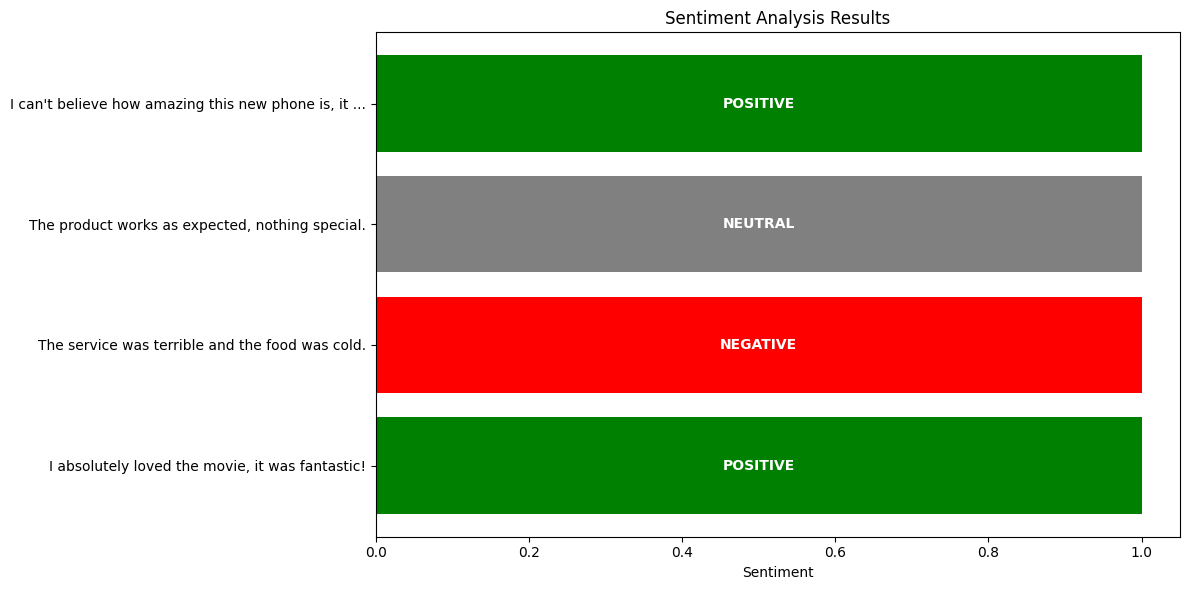

In [26]:
# Visualize sentiment results
sentiments = [result['sentiment'] for result in sentiment_results]
colors = ['green' if sentiment == 'POSITIVE' else 'red' if sentiment == 'NEGATIVE' else 'gray' for sentiment in sentiments]

plt.figure(figsize=(12, 6))
plt.barh(range(len(texts)), [1] * len(texts), color=colors)
plt.yticks(range(len(texts)), [text[:50] + '...' if len(text) > 50 else text for text in texts])
plt.xlabel('Sentiment')
plt.title('Sentiment Analysis Results')
for i, sentiment in enumerate(sentiments):
    plt.text(0.5, i, sentiment, ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Use Case: Text Summarization

Let's explore how to use the Converse API for text summarization.

In [27]:
def summarize_text(text, model_id, max_tokens=150):
    """Summarize text using Amazon Bedrock."""
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "text": f"""Please summarize the following text in a concise manner:
                    
{text}
                    
Summary:"""
                }
            ]
        }
    ]
    
    # Set inference parameters
    inference_config = {
        "temperature": 0.3,
        "maxTokens": max_tokens
    }
    
    # Call the Converse API
    response = converse(model_id, messages, inference_config=inference_config)
    
    # Extract response text
    message = response.get('output', {}).get('message', {})
    content = message.get('content', [])
    summary = ""
    for block in content:
        if 'text' in block:
            summary += block['text']
    
    return summary.strip()

In [28]:
# Example long text
long_text = """
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to intelligence displayed by animals and humans. AI research has been defined as the field of study of intelligent agents, which refers to any system that perceives its environment and takes actions that maximize its chance of achieving its goals.

The term "artificial intelligence" had previously been used to describe machines that mimic and display "human" cognitive skills that are associated with the human mind, such as "learning" and "problem-solving". This definition has since been rejected by major AI researchers who now describe AI in terms of rationality and acting rationally, which does not limit how intelligence can be articulated.

AI applications include advanced web search engines (e.g., Google), recommendation systems (used by YouTube, Amazon, and Netflix), understanding human speech (such as Siri and Alexa), self-driving cars (e.g., Waymo), generative or creative tools (ChatGPT and AI art), automated decision-making, and competing at the highest level in strategic game systems (such as chess and Go).

As machines become increasingly capable, tasks considered to require "intelligence" are often removed from the definition of AI, a phenomenon known as the AI effect. For instance, optical character recognition is frequently excluded from things considered to be AI, having become a routine technology.
"""

# Summarize the text
summary = summarize_text(long_text, model_id)

print("Original Text Length:", len(long_text.split()))
print("Summary Length:", len(summary.split()))
print("\nSummary:")
print(summary)

Original Text Length: 208
Summary Length: 94

Summary:
Certainly! Here's a concise summary:

Artificial intelligence (AI) refers to the intelligence exhibited by machines, distinct from human and animal intelligence. AI research focuses on intelligent agents—systems that perceive their environment and act to maximize goal achievement. Initially defined by mimicking human cognitive skills like learning and problem-solving, AI is now characterized by rationality and rational action. AI applications encompass advanced web search, recommendation systems, speech recognition, self-driving cars, creative tools, automated decision-making, and high-level strategic gaming. As machines advance, tasks once deemed "intelligent" are often reclassified, a phenomenon known as the AI effect.


## 13. Use Case: Creative Writing Assistant

Let's create a simple creative writing assistant using the Converse API.

In [29]:
def writing_assistant(scenario, style, length="short", model_id=model_id):
    """Generate creative writing based on a scenario and style."""
    # Map length to token count
    length_map = {
        "short": 150,
        "medium": 300,
        "long": 500
    }
    max_tokens = length_map.get(length, 200)
    
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "text": f"""Write a {style} {length} story about the following scenario:
                    
Scenario: {scenario}

Story:"""
                }
            ]
        }
    ]
    
    # Set inference parameters
    inference_config = {
        "temperature": 0.8,
        "topP": 0.9,
        "maxTokens": max_tokens
    }
    
    # Call the Converse API
    response = converse(model_id, messages, inference_config=inference_config)
    
    # Extract response text
    message = response.get('output', {}).get('message', {})
    content = message.get('content', [])
    story = ""
    for block in content:
        if 'text' in block:
            story += block['text']
    
    return story.strip()

In [30]:
# Test the writing assistant
scenario = "A detective discovers that the city's mayor is hiding a strange secret"
style = "noir"
length = "short"

print(f"Writing a {style} {length} story about: {scenario}")
story = writing_assistant(scenario, style, length)
print("\nGenerated Story:")
print(story)

Writing a noir short story about: A detective discovers that the city's mayor is hiding a strange secret

Generated Story:
### Shadows of the City

The rain fell in sheets, blurring the neon glow of the city's signs into a kaleidoscope of colors. The streets were slick, and the air was thick with the scent of wet asphalt and despair. I stood at the edge of the sidewalk, my trench coat clinging to me like a second skin, the collar turned up against the downpour. My name is Jack Malone, and I'm a detective—a profession that's as much about the shadows as it is about the light.

I had been hired by a faceless client to investigate Mayor Harold Blackwood. On the surface, Blackwood was the epitome of civic virtue: a man with a smile that could charm a snake and a reputation that seemed un


## 14. Model Evaluation and Comparison

Let's evaluate and compare different models on a simple question-answering task.

In [31]:
def evaluate_model(model_id, questions):
    """Evaluate a model on a set of questions."""
    results = []
    
    for q in questions:
        # Create message
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "text": q
                    }
                ]
            }
        ]
        
        # Set inference parameters
        inference_config = {
            "temperature": 0.2,
            "maxTokens": 100
        }
        
        # Call the Converse API and time the response
        start_time = time.time()
        response = converse(model_id, messages, inference_config=inference_config)
        response_time = time.time() - start_time
        
        # Extract response text
        message = response.get('output', {}).get('message', {})
        content = message.get('content', [])
        response_text = ""
        for block in content:
            if 'text' in block:
                response_text += block['text']
        
        # Get token usage
        usage = response.get('usage', {})
        
        results.append({
            'Question': q,
            'Response': response_text,
            'Response Time': response_time,
            'Input Tokens': usage.get('inputTokens', 'N/A'),
            'Output Tokens': usage.get('outputTokens', 'N/A')
        })
    
    return results

In [33]:
# Simple evaluation dataset
eval_questions = [
    "What is the capital of France?",
    "Who wrote 'Romeo and Juliet'?",
    "What is 7 x 8?",
    "What is the chemical symbol for gold?",
    "What year did World War II end?"
]

# List of models to evaluate
# Note: Replace these with models available in your account
models_to_evaluate = [
    "amazon.nova-micro-v1:0",
    "anthropic.claude-3-haiku-20240307-v1:0"
]

# Evaluate each model
all_results = {}
for model in models_to_evaluate:
    try:
        print(f"Evaluating {model}...")
        results = evaluate_model(model, eval_questions[:2])  # Limit to 2 questions for demo
        all_results[model] = results
        
        # Calculate average response time
        avg_time = sum(r['Response Time'] for r in results) / len(results)
        avg_output_tokens = sum(r['Output Tokens'] for r in results if isinstance(r['Output Tokens'], int)) / len(results)
        
        print(f"  Average Response Time: {avg_time:.2f} seconds")
        print(f"  Average Output Tokens: {avg_output_tokens:.1f}")
    except Exception as e:
        print(f"Error evaluating {model}: {e}")

Evaluating amazon.nova-micro-v1:0...
  Average Response Time: 0.50 seconds
  Average Output Tokens: 95.0
Evaluating anthropic.claude-3-haiku-20240307-v1:0...
  Average Response Time: 0.69 seconds
  Average Output Tokens: 55.0


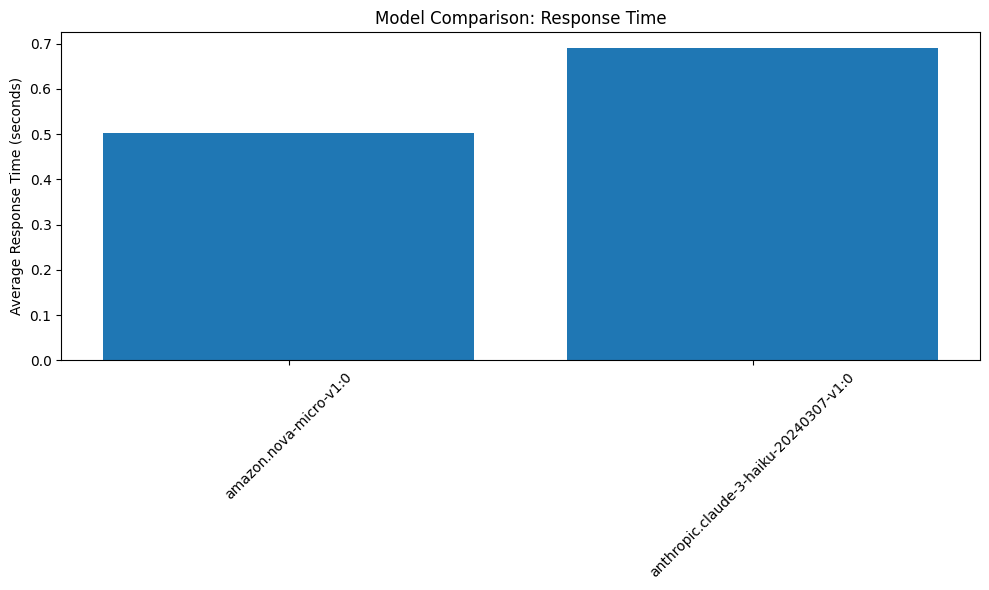


Sample response from amazon.nova-micro-v1:0:
Question: What is the capital of France?
Response: The capital of France is Paris. Paris is not only the capital city but also the most populous city in France. It is located in the northern central part of the country and is known for its significant cultural, political, and economic influence both within France and globally. Paris is famous for its landmarks such as the Eiffel Tower, the Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées, among other historic and modern attractions.

Sample response from anthropic.claude-3-haiku-20240307-v1:0:
Question: What is the capital of France?
Response: The capital of France is Paris.


In [34]:
# Visualize comparison results
if all_results:
    # Extract metrics for visualization
    model_names = list(all_results.keys())
    avg_times = [sum(r['Response Time'] for r in results) / len(results) for results in all_results.values()]
    
    # Plot response times
    plt.figure(figsize=(10, 6))
    plt.bar(model_names, avg_times)
    plt.ylabel('Average Response Time (seconds)')
    plt.title('Model Comparison: Response Time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Show a response sample for each model
    for model, results in all_results.items():
        print(f"\nSample response from {model}:")
        print(f"Question: {results[0]['Question']}")
        print(f"Response: {results[0]['Response']}")

## 15. Ethical Considerations and Responsible Use

When working with LLMs through Amazon Bedrock, it's important to consider several ethical aspects:

1. **Bias and Fairness**: LLMs can inherit biases from their training data, potentially reinforcing stereotypes or producing unfair outcomes.

2. **Privacy Concerns**: Models might memorize and reproduce sensitive information from their training data.

3. **Misinformation**: LLMs can generate plausible-sounding but incorrect information.

4. **Energy Consumption**: Running inference on large models requires computational resources and energy.

5. **Appropriate Use Cases**: Consider whether an LLM is the appropriate tool for a given task.

### Mitigation Strategies:

- **Input Validation**: Implement validation checks on prompts
- **Output Filtering**: Apply post-processing to filter harmful content
- **User Feedback**: Collect and incorporate user feedback to improve model outputs
- **Transparency**: Be clear about model limitations and the AI-generated nature of content
- **Model Selection**: Choose the right model for your use case based on requirements and constraints

## 16. Conclusion and Best Practices

### Best Practices for Working with Amazon Bedrock

1. **Choose the Right Model**: Select models based on your specific needs, considering factors like performance, cost, and latency.

2. **Optimize Prompts**: Carefully design and test prompts to get the best results from the model.

3. **Set Appropriate Parameters**: Adjust temperature, max tokens, and other parameters based on your use case.

4. **Implement Safety Measures**: Add filters and validations for both inputs and outputs.

5. **Monitor Usage**: Track performance, costs, and user feedback to continuously improve your implementation.

6. **Handle Rate Limits**: Implement appropriate retry strategies and rate limiting to handle API limits.

7. **Set Clear Expectations**: Be transparent with users about model capabilities and limitations.

### Key Takeaways

- Amazon Bedrock provides access to powerful foundation models through the Converse API
- Understanding model parameters like temperature and top-p is crucial for controlling outputs
- Different models excel at different tasks, so choose the right model for your use case
- Ethical considerations and safeguards should be implemented for responsible use

## Resources

- [Amazon Bedrock Developer Guide](https://docs.aws.amazon.com/bedrock/)
- [Amazon Bedrock API Reference](https://docs.aws.amazon.com/bedrock/latest/APIReference/)
- [AWS SDK for Python (boto3) Documentation](https://boto3.amazonaws.com/v1/documentation/api/latest/reference/services/bedrock.html)
- [Amazon Bedrock Samples](https://github.com/aws-samples/amazon-bedrock-samples)